In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
df = pd.read_csv("../data/cleaned_retail.csv")

print(df.shape)

(392693, 16)


In [3]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392693 entries, 0 to 392692
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Invoice            392693 non-null  int64         
 1   StockCode          392693 non-null  object        
 2   Description        392693 non-null  object        
 3   Quantity           392693 non-null  int64         
 4   InvoiceDate        392693 non-null  datetime64[ns]
 5   Price              392693 non-null  float64       
 6   Customer ID        392693 non-null  float64       
 7   Country            392693 non-null  object        
 8   TotalAmount        392693 non-null  float64       
 9   Year               392693 non-null  int64         
 10  Month              392693 non-null  int64         
 11  Day                392693 non-null  int64         
 12  Weekday            392693 non-null  object        
 13  Quarter            392693 non-null  int64   

In [4]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount,Year,Month,Day,Weekday,Quarter,CustomerFrequency,OrderSize
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1,Wednesday,4,297,Small
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,4,297,Small
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1,Wednesday,4,297,Small
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,4,297,Small
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1,Wednesday,4,297,Small


In [5]:
daily_sales = df.groupby(
    df["InvoiceDate"].dt.date
)["TotalAmount"].sum()

In [6]:
daily_sales = daily_sales.reset_index()

daily_sales.columns = [
    "Date",
    "Sales"
]

daily_sales.head()

,Date,Sales
0,2010-12-01,46192.49
1,2010-12-02,47197.57
2,2010-12-03,23876.63
3,2010-12-05,31361.28
4,2010-12-06,31009.33


In [7]:
print(daily_sales.shape)

(305, 2)


In [8]:
daily_sales.to_csv(
    "../data/daily_sales.csv",
    index=False
)

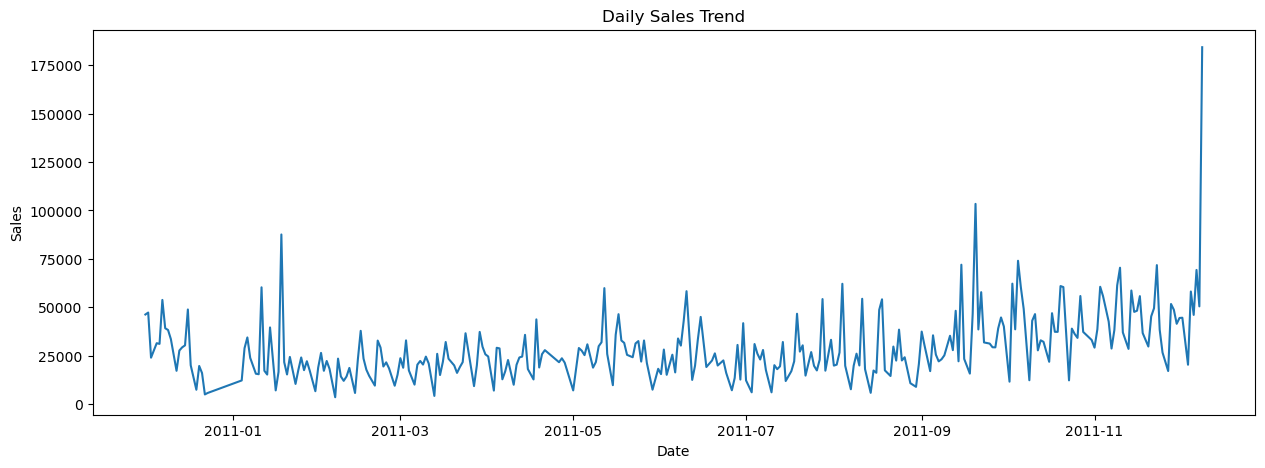

In [9]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"]
)

plt.title(
    "Daily Sales Trend"
)

plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [10]:
daily_sales["MA7"] = (
    daily_sales["Sales"]
    .rolling(window=7)
    .mean()
)

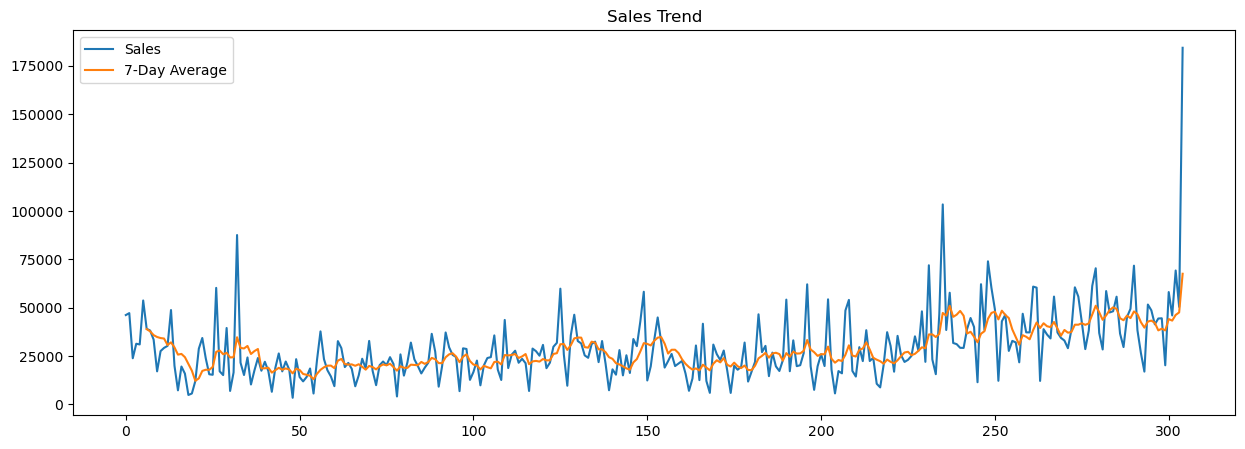

In [11]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Sales"],
    label="Sales"
)

plt.plot(
    daily_sales["MA7"],
    label="7-Day Average"
)

plt.legend()

plt.title(
    "Sales Trend"
)

plt.show()

In [12]:
result = adfuller(
    daily_sales["Sales"]
)

print("ADF Statistic:",
      result[0])

print("p-value:",
      result[1])

ADF Statistic: -0.3708089838467215
p-value: 0.9148597313525861


In [13]:
daily_sales["Date"] = pd.to_datetime(
    daily_sales["Date"]
)

daily_sales.set_index(
    "Date",
    inplace=True
)

In [14]:
decomposition = seasonal_decompose(
    daily_sales["Sales"],
    model="additive",
    period=30
)

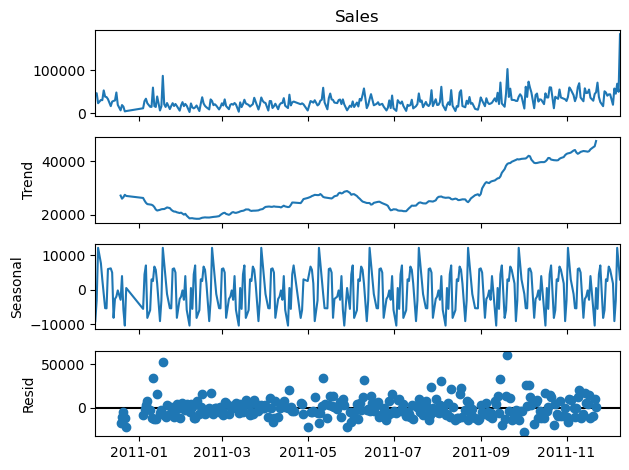

In [15]:
decomposition.plot()

plt.show()

In [16]:
daily_sales.index = pd.to_datetime(
    daily_sales.index
)

print(
    daily_sales.index.is_monotonic_increasing
)

True


In [17]:
daily_sales.to_csv(
    "../data/time_series_prepared.csv"
)